# HAE hierarchical reconstruction manual eval

手动选择两层 HAE 的 checkpoint、样本和变量，比较：

- `top_only`: 只用 top latent 解码，bottom latent 置空
- `top+bottom`: 同时使用 top latent 和 bottom latent 解码

误差同时给出 normalized L1/MSE、训练日志同口径的 denormalized 分变量 L1，以及常看变量的单通道误差。


In [37]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

ROOT = Path("/mnt/petrelfs/fanhang/HAE")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.config import load_config
from utils.builder import ConfigBuilder
from trainers.ae_kl_trainer import STD_LAYER

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)
print("device:", DEVICE)
print("root:", ROOT)


device: cuda:0
root: /mnt/petrelfs/fanhang/HAE


In [38]:
# ===== 手动改这里 =====
# 默认是当前 4 卡 20 epoch 的 balanced 两层 HAE。
# RUN_DIR = ROOT / "output" / "AE_hybrid_hier2_34_balanced_ae20"
# CONFIG_PATH = ROOT / "configs" / "ae_kl_hybrid_hier2_34_balanced_ae20.yaml"
# CHECKPOINT_PATH = RUN_DIR / "best.pth"

# 也可以切到之前 bottom-drop 版本：
RUN_DIR = ROOT / "output" / "AE_KL_hybrid_hier2_34_full"
CONFIG_PATH = ROOT / "configs" / "ae_kl_hybrid_hier2_34_full.yaml"
CHECKPOINT_PATH = RUN_DIR / "best.pth"

SPLIT = "valid"      # valid / test / train
SAMPLE_INDEX = 0      # 手动选择 case
CHANNEL_NAME = "z_500"

print("config:", CONFIG_PATH)
print("checkpoint:", CHECKPOINT_PATH)
print("exists:", CHECKPOINT_PATH.exists())


config: /mnt/petrelfs/fanhang/HAE/configs/ae_kl_hybrid_hier2_34_full.yaml
checkpoint: /mnt/petrelfs/fanhang/HAE/output/AE_KL_hybrid_hier2_34_full/best.pth
exists: True


In [39]:
SINGLE_LEVEL_NAMES = ["msl", "u10", "v10", "t2m"]
HEIGHT_LEVELS = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
MULTI_LEVEL_NAMES = ["z", "q", "u", "v", "t"]
CHANNEL_NAMES = SINGLE_LEVEL_NAMES + [f"{v}_{h}" for v in MULTI_LEVEL_NAMES for h in HEIGHT_LEVELS]
CHANNEL_TO_INDEX = {name: i for i, name in enumerate(CHANNEL_NAMES)}

GROUP_SLICES = {
    "z": slice(4, 17),
    "q": slice(17, 30),
    "u": slice(30, 43),
    "v": slice(43, 56),
    "t": slice(56, 69),
}

SELECTED_CHANNELS = ["z_500", "t_850", "u_850", "v_850", "t2m", "msl"]

assert CHANNEL_TO_INDEX["z_500"] == 11
print("num channels:", len(CHANNEL_NAMES), "z_500 index:", CHANNEL_TO_INDEX["z_500"])


num channels: 69 z_500 index: 11


In [40]:
def _strip_module_prefix(state_dict):
    if not any(k.startswith("module.") for k in state_dict):
        return state_dict
    return {k[len("module."):]: v for k, v in state_dict.items()}


def load_model(config_path, checkpoint_path, device):
    cfg = load_config(str(config_path))
    builder = ConfigBuilder(cfg)
    model = builder.build_model().to(device).eval()

    ckpt = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(ckpt, dict):
        state = ckpt.get("MODEL_STATE") or ckpt.get("MODEL") or ckpt.get("model") or ckpt.get("state_dict") or ckpt
    else:
        state = ckpt
    state = _strip_module_prefix(state)
    missing, unexpected = model.load_state_dict(state, strict=False)

    print("loaded model:", type(model).__name__)
    print("missing keys:", len(missing), "unexpected keys:", len(unexpected))
    if missing[:5]:
        print("missing first keys:", missing[:5])
    if unexpected[:5]:
        print("unexpected first keys:", unexpected[:5])
    return cfg, builder, model


cfg, builder, model = load_model(CONFIG_PATH, CHECKPOINT_PATH, DEVICE)
dataset = builder.build_dataset(SPLIT)
print("dataset length:", len(dataset))


/tmp/ipykernel_170447/1750540662.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location="cpu")


loaded model: HybridHier2VAEformer
missing keys: 1 unexpected keys: 0
missing first keys: ['bottom_fuse_scale']
dataset length: 1251


In [41]:
def to_batch(sample, device):
    if isinstance(sample, (tuple, list)):
        sample = sample[0]
    if isinstance(sample, np.ndarray):
        sample = torch.from_numpy(sample)
    sample = sample.float()
    if sample.ndim == 3:
        sample = sample.unsqueeze(0)
    return sample.to(device, non_blocking=True)


def posterior_mode(posterior):
    return posterior.mode() if hasattr(posterior, "mode") else posterior


x = to_batch(dataset[SAMPLE_INDEX], DEVICE)
print("x shape:", tuple(x.shape), "min/max:", float(x.min()), float(x.max()))

with torch.no_grad():
    posteriors = model.encode(x)
    z_top = posterior_mode(posteriors["top"])
    z_bottom = posterior_mode(posteriors["bottom"])
    recon_top = model.decode(z_top, None)
    recon_full = model.decode(z_top, z_bottom)

print("z_top:", tuple(z_top.shape), "elements/sample:", int(np.prod(z_top.shape[1:])))
print("z_bottom:", tuple(z_bottom.shape), "elements/sample:", int(np.prod(z_bottom.shape[1:])))
print("latent total:", int(np.prod(z_top.shape[1:]) + np.prod(z_bottom.shape[1:])))
print("recon_top:", tuple(recon_top.shape), "recon_full:", tuple(recon_full.shape))


x shape: (1, 69, 128, 256) min/max: -5.154877662658691 5.891878604888916
z_top: (1, 34, 8, 16) elements/sample: 4352
z_bottom: (1, 34, 32, 64) elements/sample: 69632
latent total: 73984
recon_top: (1, 69, 128, 256) recon_full: (1, 69, 128, 256)


In [42]:
STD = torch.tensor(STD_LAYER, dtype=torch.float32, device=DEVICE).view(1, -1, 1, 1)


def denorm(t):
    # 和 trainer validate 一致：这里只乘 std，不加 mean。
    return t * STD


def reconstruction_metrics(pred, target, name):
    pred_d = denorm(pred)
    target_d = denorm(target)
    row = {
        "case": name,
        "norm_l1": float(F.l1_loss(pred, target).item()),
        "norm_mse": float(F.mse_loss(pred, target).item()),
        "denorm_l1_all": float(F.l1_loss(pred_d, target_d).item()),
    }
    for group_name, sl in GROUP_SLICES.items():
        row[f"{group_name}_err"] = float(F.l1_loss(pred_d[:, sl], target_d[:, sl]).item())
    for ch_name in SELECTED_CHANNELS:
        ch = CHANNEL_TO_INDEX[ch_name]
        row[f"{ch_name}_mae"] = float(F.l1_loss(pred_d[:, ch], target_d[:, ch]).item())
    return row


metrics_df = pd.DataFrame([
    reconstruction_metrics(recon_top, x, "top_only"),
    reconstruction_metrics(recon_full, x, "top+bottom"),
])
metrics_df


,case,norm_l1,norm_mse,denorm_l1_all,z_err,q_err,u_err,v_err,t_err,z_500_mae,t_850_mae,u_850_mae,v_850_mae,t2m_mae,msl_mae
0,top_only,0.140094,0.051010,36.468979,181.011749,0.000275,1.960186,1.838352,1.026407,192.130692,1.356003,1.61636,1.417143,94.911575,0.368217
1,top+bottom,0.075062,0.015704,11.044080,51.037468,0.000159,1.115275,0.978616,0.587589,44.768291,0.760805,0.96183,0.835583,60.725929,0.208495


In [43]:
compare = metrics_df.set_index("case")
improve = (compare.loc["top_only"] - compare.loc["top+bottom"]) / compare.loc["top_only"].replace(0, np.nan)
improve = improve.to_frame("relative_improvement_full_vs_top_only")
improve


,relative_improvement_full_vs_top_only
norm_l1,0.464204
norm_mse,0.692142
denorm_l1_all,0.697165
z_err,0.718043
q_err,0.420670
u_err,0.431036
v_err,0.467667
t_err,0.427528
z_500_mae,0.766990
t_850_mae,0.438936


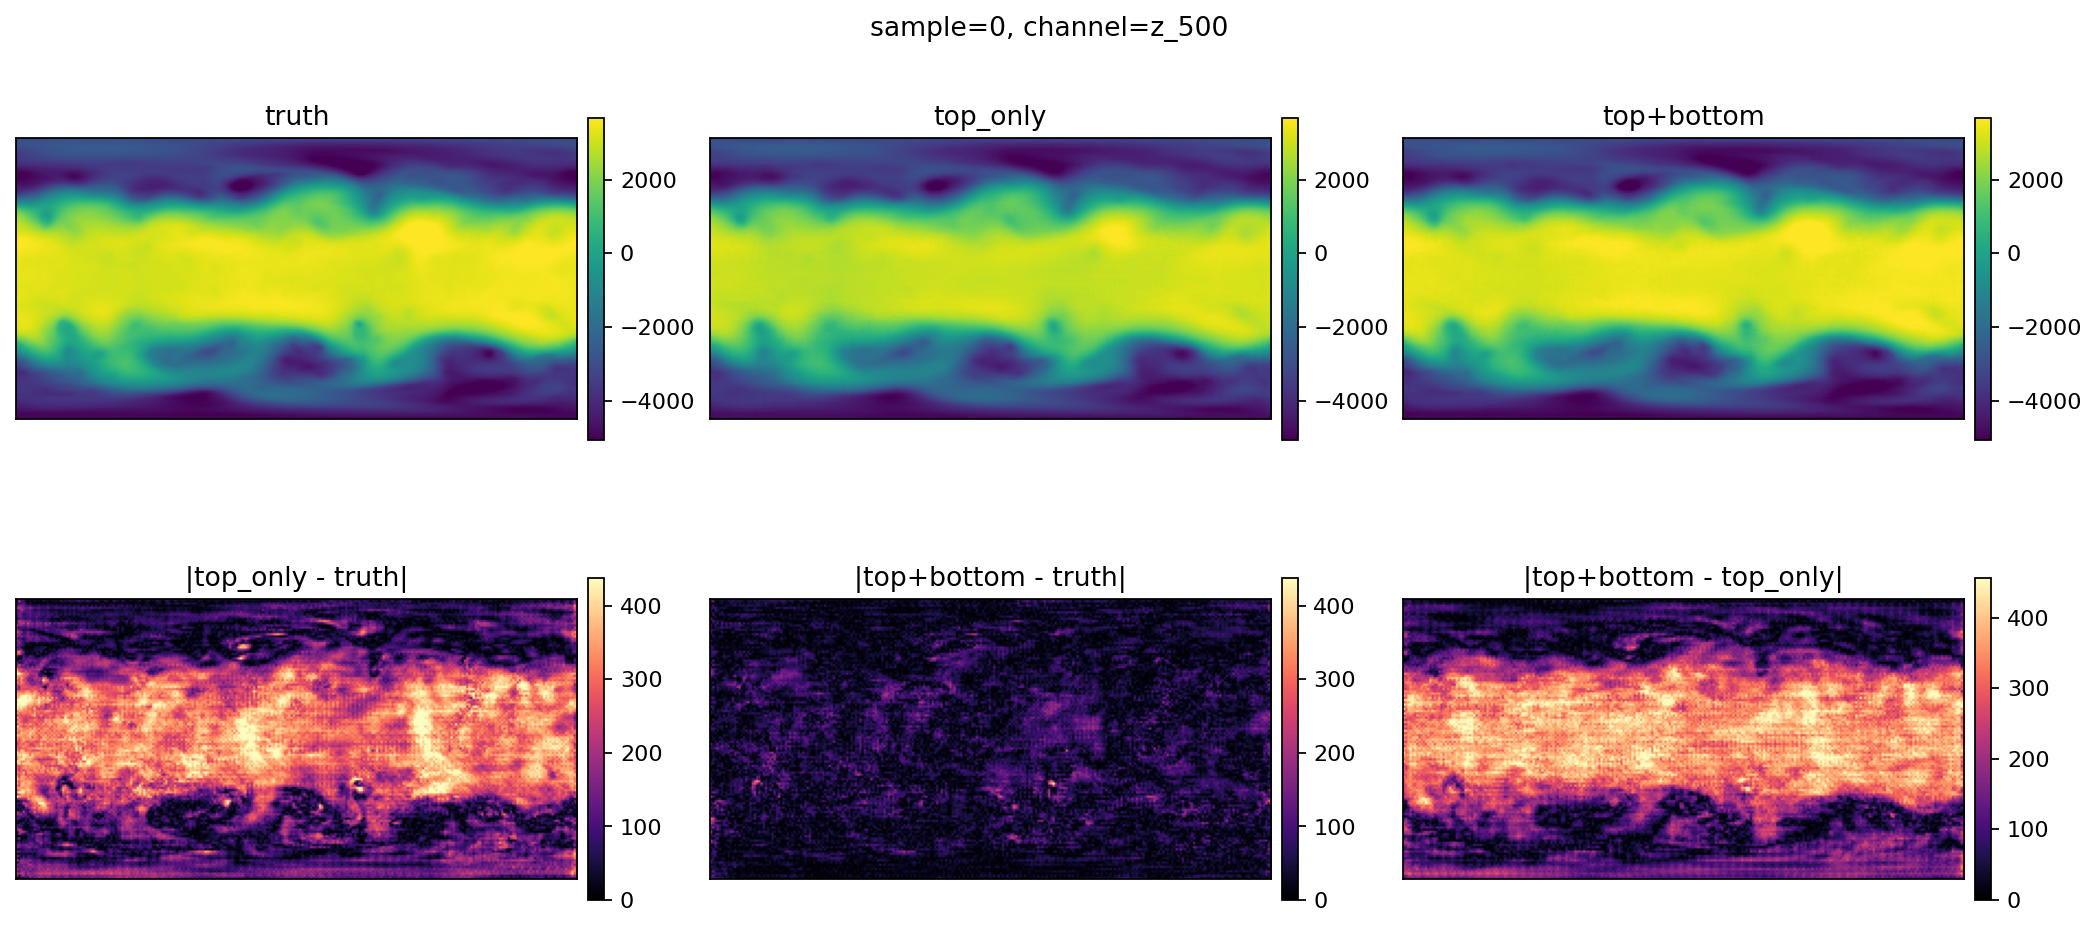

In [44]:
def plot_channel(channel_name=CHANNEL_NAME):
    ch = CHANNEL_TO_INDEX[channel_name]
    truth = denorm(x)[0, ch].detach().cpu().numpy()
    top = denorm(recon_top)[0, ch].detach().cpu().numpy()
    full = denorm(recon_full)[0, ch].detach().cpu().numpy()

    # Keep prediction-minus-truth signed. Only the top+bottom vs top-only delta is absolute.
    err_top = top - truth
    err_full = full - truth
    delta_abs = np.abs(full - top)

    vmin, vmax = np.percentile(truth, [1, 99])
    err_abs = max(
        abs(np.percentile(err_top, 1)),
        abs(np.percentile(err_top, 99)),
        abs(np.percentile(err_full, 1)),
        abs(np.percentile(err_full, 99)),
        1e-12,
    )
    delta_vmax = max(np.percentile(delta_abs, 99), 1e-12)

    fig, axs = plt.subplots(2, 3, figsize=(13, 6), dpi=160, constrained_layout=True)
    images = [
        (truth, "truth", "viridis", vmin, vmax),
        (top, "top_only", "viridis", vmin, vmax),
        (full, "top+bottom", "viridis", vmin, vmax),
        (err_top, "top_only - truth", "coolwarm", -err_abs, err_abs),
        (err_full, "top+bottom - truth", "coolwarm", -err_abs, err_abs),
        (delta_abs, "|top+bottom - top_only|", "magma", 0, delta_vmax),
    ]
    for ax, (arr, title, cmap, lo, hi) in zip(axs.ravel(), images):
        im = ax.imshow(arr, cmap=cmap, vmin=lo, vmax=hi, origin="lower")
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.032, pad=0.02, shrink=0.72)
    fig.suptitle(f"sample={SAMPLE_INDEX}, channel={channel_name}")
    return fig

plot_channel(CHANNEL_NAME);


In [45]:
# 可选：快速扫多个样本，查看 top_only 和 top+bottom 的平均误差。
NUM_SAMPLES = 100
START_INDEX = 0

rows = []
for idx in range(START_INDEX, START_INDEX + NUM_SAMPLES):
    x_i = to_batch(dataset[idx], DEVICE)
    with torch.no_grad():
        p_i = model.encode(x_i)
        zt_i = posterior_mode(p_i["top"])
        zb_i = posterior_mode(p_i["bottom"])
        top_i = model.decode(zt_i, None)
        full_i = model.decode(zt_i, zb_i)
    rows.append({"sample": idx, **reconstruction_metrics(top_i, x_i, "top_only")})
    rows.append({"sample": idx, **reconstruction_metrics(full_i, x_i, "top+bottom")})

batch_df = pd.DataFrame(rows)
summary_df = batch_df.groupby("case").mean(numeric_only=True)
summary_df


,sample,norm_l1,norm_mse,denorm_l1_all,z_err,q_err,u_err,v_err,t_err,z_500_mae,t_850_mae,u_850_mae,v_850_mae,t2m_mae,msl_mae
case,,,,,,,,,,,,,,,
top+bottom,3.5,0.075085,0.015786,11.604200,54.082627,0.000159,1.111902,0.976983,0.588519,49.067088,0.764368,0.958249,0.832995,59.845375,0.208413
top_only,3.5,0.139809,0.051253,35.824947,177.695066,0.000277,1.950109,1.848904,1.016771,188.269831,1.332694,1.587626,1.373920,93.773878,0.360901


In [46]:
# 如果要释放 notebook 里的 petrel worker / shared memory，最后执行这个单元。
try:
    dataset.close()
    print("dataset closed")
except Exception as exc:
    print("close skipped:", repr(exc))


dataset closed
